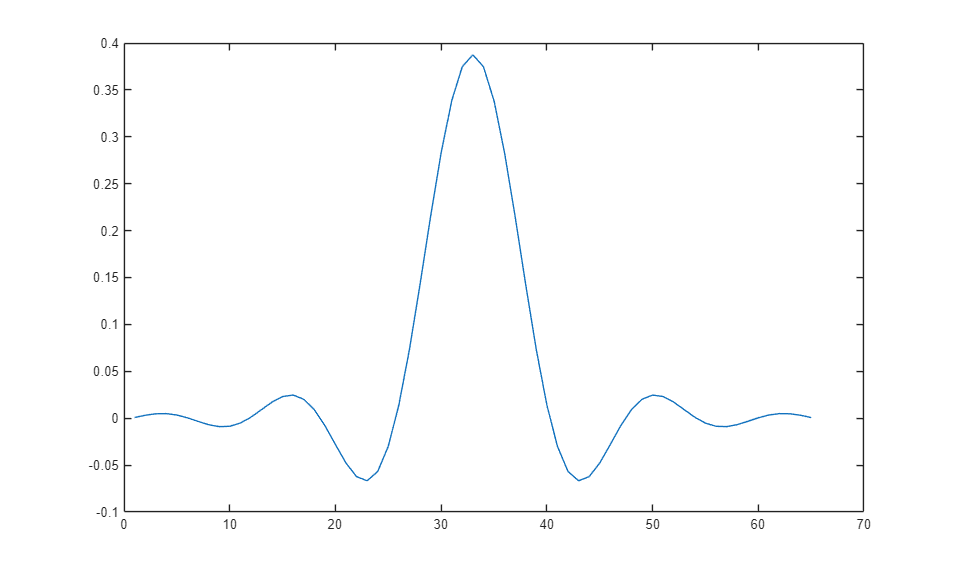

In [1]:
alpha = 0.35;    % Match cellular standards
span = 8;        % Slightly wider span for accuracy
sps = 8;         % High fidelity sampling

h = rcosdesign(alpha, span, sps, 'sqrt'); % 'sqrt' for Root Raised Cosine (standard)


figure();
plot(h);

In [2]:
M = 64;

data = randi([0 M-1], 10000, 1);
qamSig = qammod(data, M);

% 2. Apply the Raised Cosine Filter
% This automatically upsamples by 'sps' and applies the filter 'h'
txWaveform = upfirdn(qamSig, h, sps);

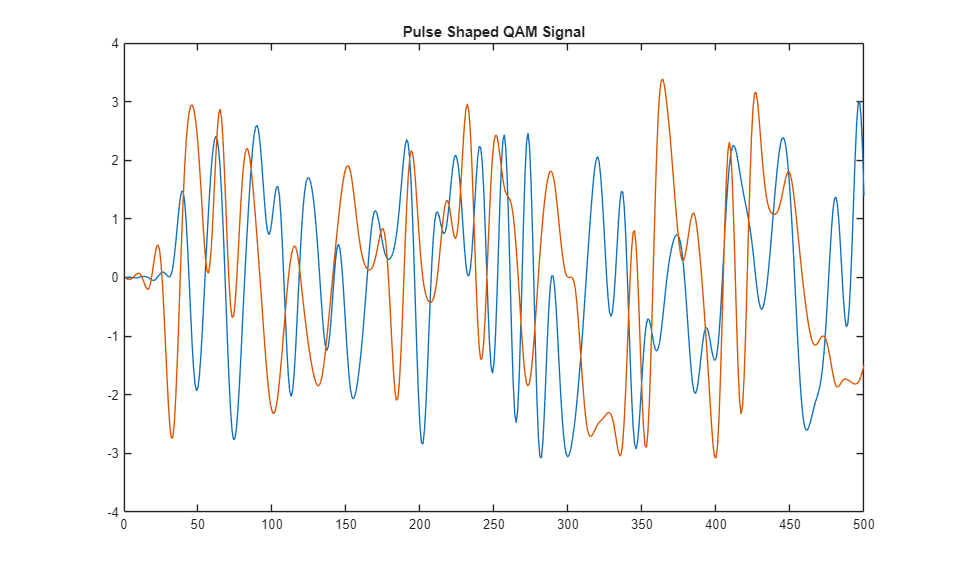

In [3]:


N = 500;



% 3. Plot a snippet of the waveform
figure;
plot(real(txWaveform(1:N))); % Viewing In-Phase component only

hold on;

plot(imag(txWaveform(1:N))); % Viewing In-Phase component only

title('Pulse Shaped QAM Signal');

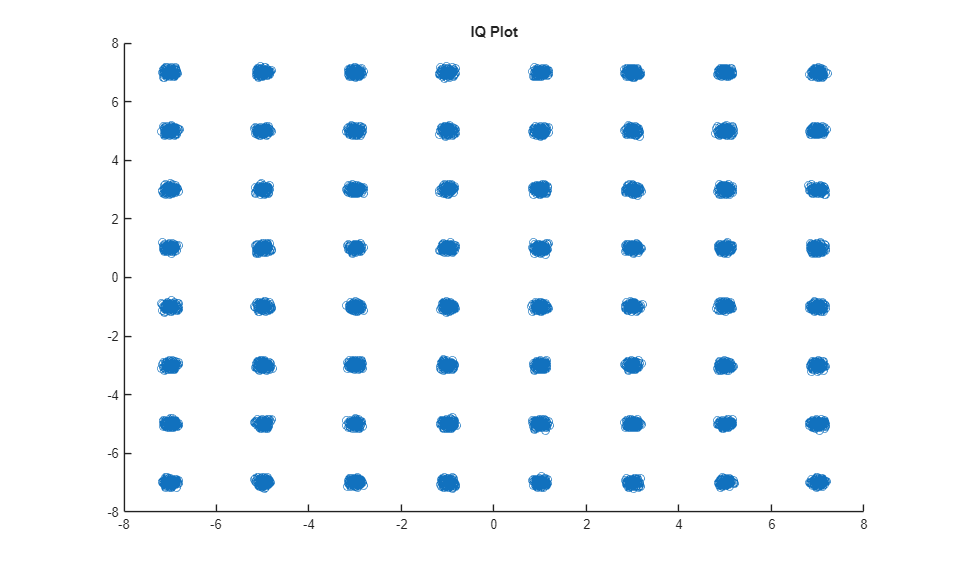

In [4]:
numSymbols = length(data);

rxFiltered = upfirdn(txWaveform, h, 1); 

% 6. Synchronize and Downsample
% The total delay is the sum of both filters.
% Tx Delay = (span*sps)/2
% Rx Delay = (span*sps)/2
% Total Delay = span * sps
totalDelay = span * sps;

% Start reading after the delay to skip the "ramp up"
rxSampled = rxFiltered(totalDelay + 1 : sps : end);

% 7. *** THE FIX FOR THE CENTER DOT ***
% 'upfirdn' outputs a longer signal than input to capture the "ramp down".
% These extra samples trail off to zero, causing the dot at 0,0.
% We simply truncate the vector to the original number of symbols.
rxRecovered = rxSampled(1:numSymbols);

% 8. Plot
figure();
scatter(real(rxRecovered), imag(rxRecovered))
title('IQ Plot');

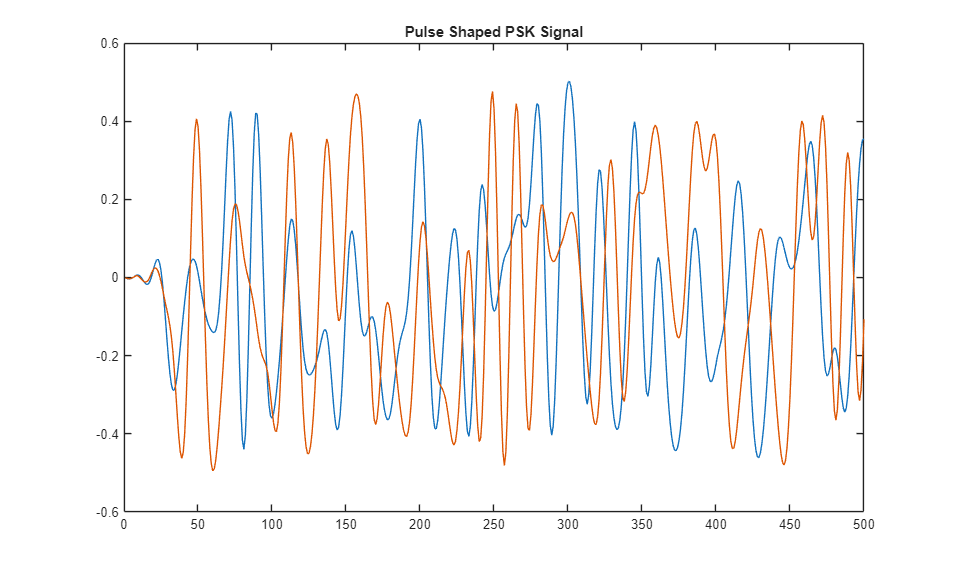

In [22]:
M = 64;

pskSig = pskmod(data, M);

txWaveform = upfirdn(pskSig, h, sps);


N = 500;



% 3. Plot a snippet of the waveform
figure;
plot(real(txWaveform(1:N))); % Viewing In-Phase component only

hold on;

plot(imag(txWaveform(1:N))); % Viewing In-Phase component only

title('Pulse Shaped PSK Signal');


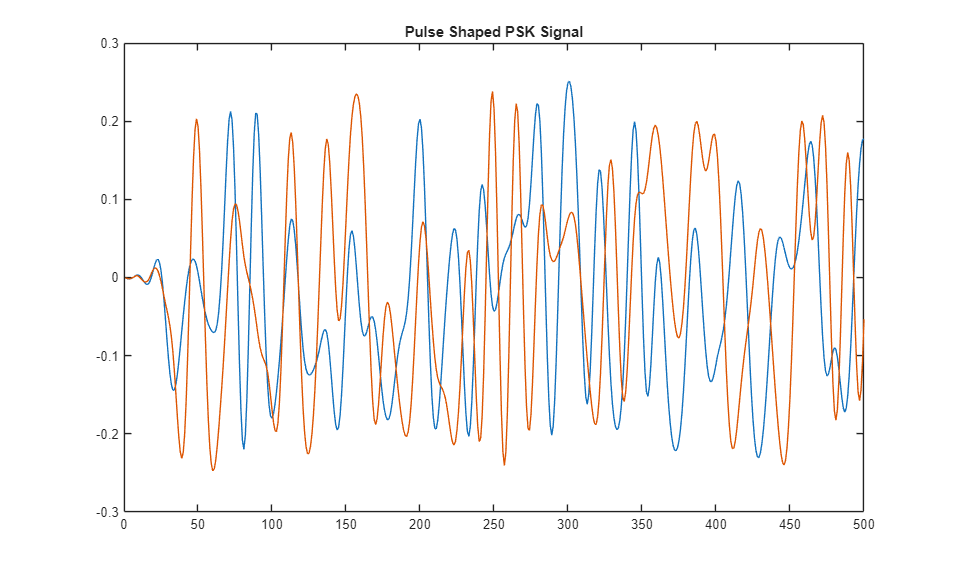

In [26]:


txWaveform2 = (1/2)*upfirdn(pskSig, h, sps);


N = 500;



% 3. Plot a snippet of the waveform
figure;
plot(real(txWaveform2(1:N))); % Viewing In-Phase component only

hold on;

plot(imag(txWaveform2(1:N))); % Viewing In-Phase component only

title('Pulse Shaped PSK Signal');


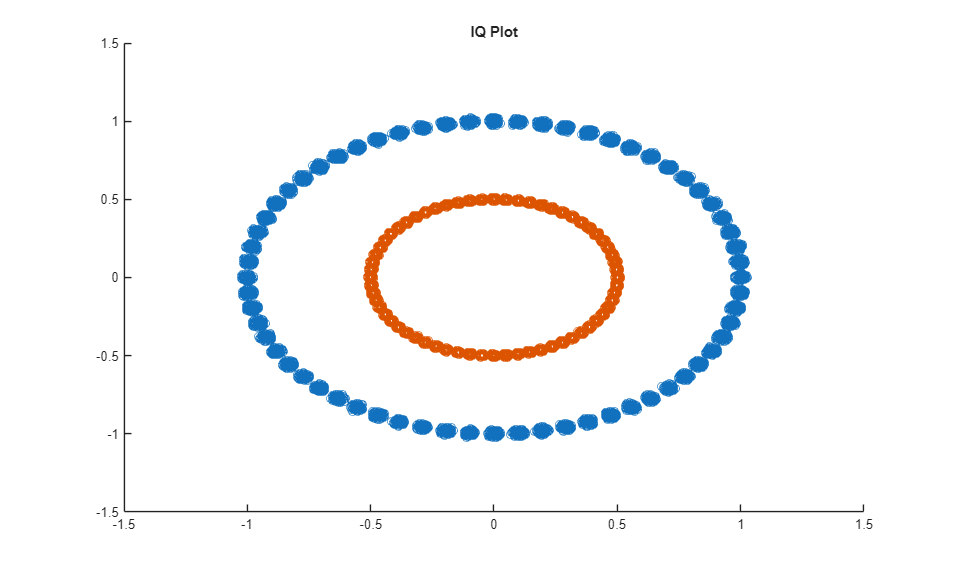

In [28]:
numSymbols = length(data);

rxFiltered = upfirdn(txWaveform, h, 1); 


totalDelay = span * sps;

rxSampled = rxFiltered(totalDelay + 1 : sps : end);


rxRecovered = rxSampled(1:numSymbols);

figure();
scatter(real(rxRecovered), imag(rxRecovered))
title('IQ Plot');
hold on;

numSymbols = length(data);

rxFiltered = upfirdn(txWaveform2, h, 1); 


totalDelay = span * sps;

rxSampled = rxFiltered(totalDelay + 1 : sps : end);

rxRecovered = rxSampled(1:numSymbols);


scatter(real(rxRecovered), imag(rxRecovered))


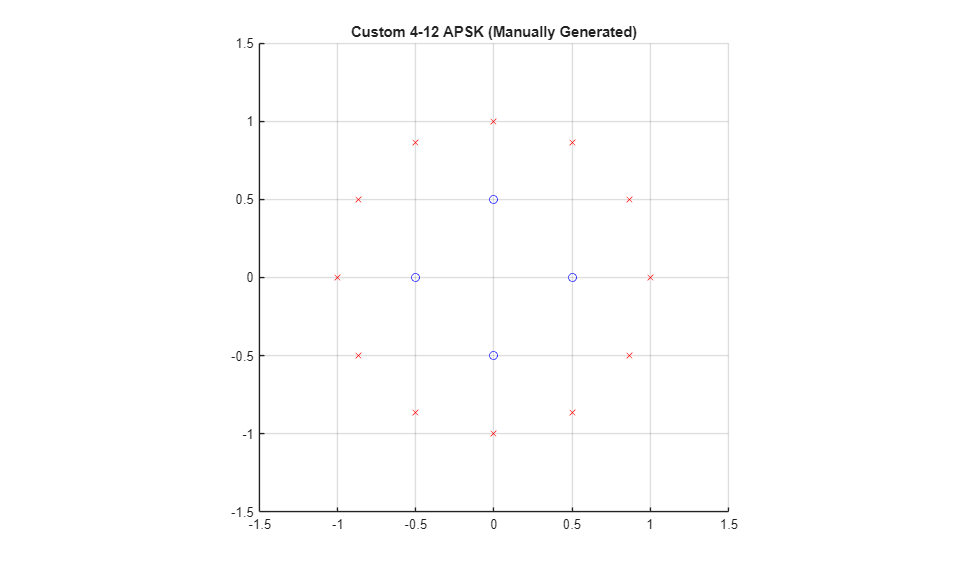

In [31]:
% Configuration
M_inner = 4;
M_outer = 12;

% --- 1. Inner Ring (Standard 4-PSK) ---
% Since 4 is a power of 2, pskmod works here (or use math below)
data_inner = randi([0 M_inner-1], 100, 1);
% Radius 0.5
sig_inner = 0.5 * pskmod(data_inner, M_inner); 

% --- 2. Outer Ring (12-PSK - The Fix) ---
% We cannot use pskmod(x, 12). We calculate coordinates manually.
data_outer = randi([0 M_outer-1], 100, 1);

% Calculate the angle for each integer symbol (0 to 11)
% Angle = 2*pi * (symbol / TotalSymbols)
theta = (2*pi * data_outer) / M_outer;

% Convert Polar to Cartesian (Radius * e^(j*theta))
radius_outer = 1.0;
sig_outer = radius_outer * exp(1j * theta);

% --- Plot ---
figure;
hold on;
plot(real(sig_inner), imag(sig_inner), 'bo'); % Blue inner
plot(real(sig_outer), imag(sig_outer), 'rx'); % Red outer
grid on;
axis square;
title('Custom 4-12 APSK (Manually Generated)');
xlim([-1.5 1.5]); ylim([-1.5 1.5]);

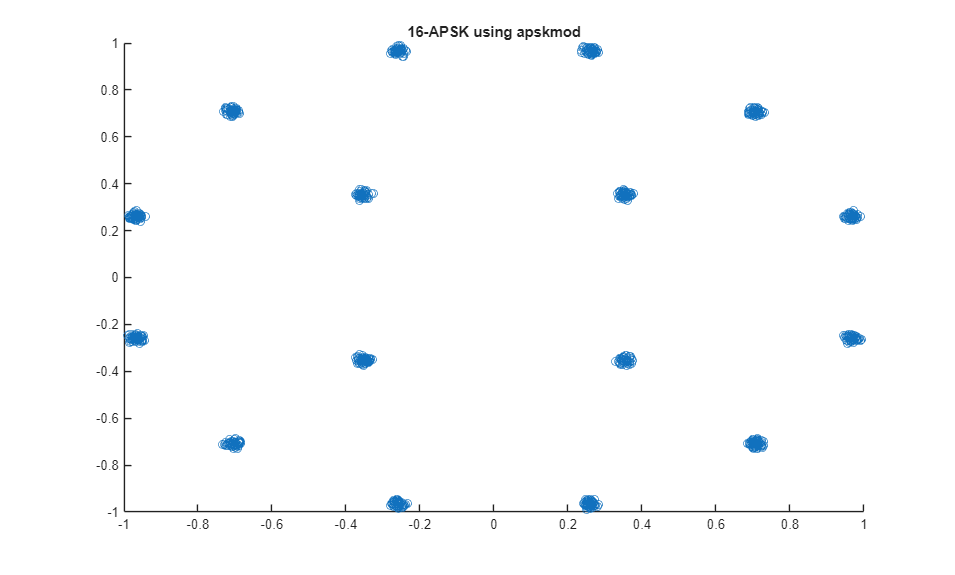

In [ ]:
% Define the structure: 4 points on inner ring, 12 on outer
M_vector = [4 12]; 

% Define radii for the rings
radii = [0.5 1.0];

% Generate random integers
% The total modulation order is 4 + 12 = 16
total_M = sum(M_vector); 
data = randi([0 total_M-1], 1000, 1);
numSymbols = length(data);
% Modulate using the specific APSK function
txSig = apskmod(data, M_vector, radii);

txWaveform = upfirdn(txSig, h, sps);


rxFiltered = upfirdn(txWaveform, h, 1); 


totalDelay = span * sps;

rxSampled = rxFiltered(totalDelay + 1 : sps : end);


rxRecovered = rxSampled(1:numSymbols);


% Plot
figure();
scatter(real(rxRecovered), imag(rxRecovered))
title('16-APSK using apskmod');